# V. orders.csv — Đơn hàng

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

In [2]:
orders_df.head(10)

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign
5,7,2012-07-06,57820,2886,delivered,credit_card,tablet,organic_search
6,8,2012-07-06,57818,2886,delivered,credit_card,mobile,email_campaign
7,9,2012-07-06,49102,5262,delivered,apple_pay,tablet,paid_search
8,10,2012-07-06,49101,5262,delivered,paypal,desktop,organic_search
9,13,2012-07-06,40638,7456,delivered,credit_card,tablet,social_media


In [5]:
orders_df.shape

(646945, 8)

In [3]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  object        
 5   payment_method  646945 non-null  object        
 6   device_type     646945 non-null  object        
 7   order_source    646945 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 39.5+ MB


In [4]:
orders_df.columns

Index(['order_id', 'order_date', 'customer_id', 'zip', 'order_status',
       'payment_method', 'device_type', 'order_source'],
      dtype='object')

## 1.1. Phân tích đơn biến

### 1.1.1. Biến số (Numerous)

#### a. Phân phối và outlier

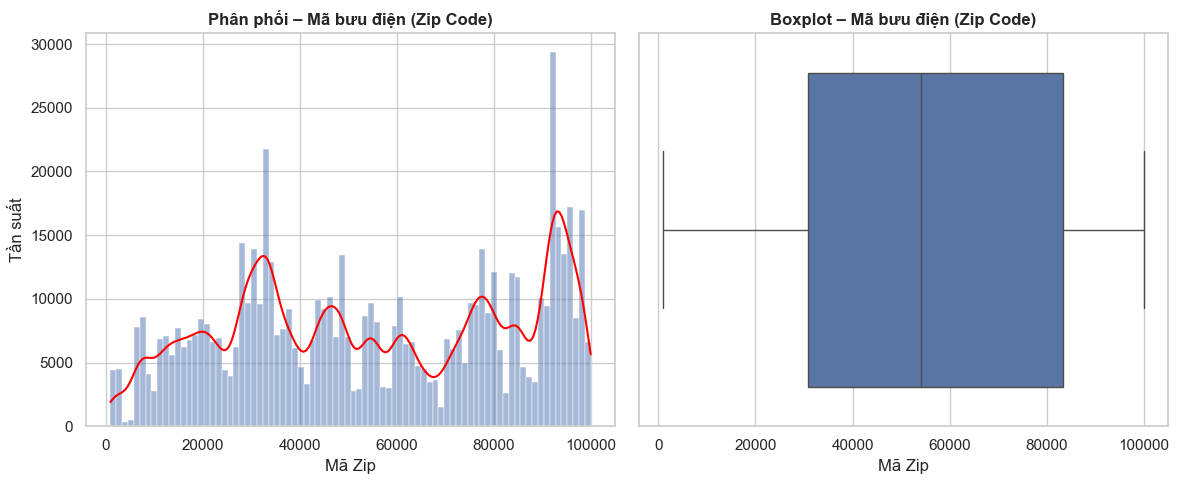

In [9]:
col_config = {
    'zip': {'title': 'Mã bưu điện (Zip Code)', 'xlabel': 'Mã Zip'}
}

# Danh sách các cột cần vẽ


# 3. Hàm vẽ biểu đồ phân phối (Histogram + KDE)
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid). Chỉnh lại logic nếu n = 1
    cols = 2 if n > 1 else 1
    rows = math.ceil(n / cols) if n > 1 else 1
    
    plt.figure(figsize=(6 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# 4. Hàm vẽ kết hợp Distribution và Boxplot
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        # Bắt lỗi nếu không có đường KDE
        if ax.lines:
            ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    plt.show()

# 5. Gọi hàm thực thi và lưu ảnh
con_cols_names = ['zip']
plot_distribution_boxplot(orders_df, con_cols_names)

In [11]:
orders_df['zip'].value_counts()

zip
93065    574
92592    514
90250    399
92882    386
93536    373
        ... 
77446      1
71969      1
33694      1
42275      1
31827      1
Name: count, Length: 29932, dtype: int64

**Nhận xét:**

- **Quan sát:**
  - Mã bưu điện (Zip Code): Dữ liệu phân bố trải dài trên toàn bộ thang đo từ 0 đến khoảng 100.000. Biểu đồ Histogram thể hiện rõ hình dạng phân phối đa đỉnh (multimodal). Có sự tập trung tần suất đột biến tại một số cụm mã định sẵn: cao nhất là dải quanh mức 90.000 - 95.000 (đạt gần 30.000 lượt), tiếp theo là cụm 30.000 - 35.000 (vượt mức 20.000 lượt) và các đỉnh nhỏ hơn ở mốc 45.000, 75.000.
  - Biểu đồ Boxplot cho thấy dữ liệu phân tán khá rộng nhưng có tính đối xứng tương đối. Trung vị (median) nằm ở khoảng 55.000, khoảng tứ phân vị (IQR) bao trùm từ 30.000 đến khoảng 85.000. Đặc biệt, không xuất hiện các điểm dữ liệu ngoại lai (outliers) ở cả hai đầu mút của dải phân phối.

- **Insights:**
  - Về mức độ tập trung địa lý: Vì Mã bưu điện là dữ liệu đại diện cho vùng địa lý, biểu đồ đa đỉnh chứng tỏ tệp khách hàng/giao dịch không phân bố đều mà tập trung cực kỳ mạnh vào một vài khu vực/tỉnh thành trọng điểm (ví dụ: các thành phố lớn hoặc khu trung tâm kinh tế). Vùng ứng với dải mã 90.000+ đang là thị trường chủ lực đem lại khối lượng dữ liệu/đơn hàng áp đảo.
  - Về chất lượng dữ liệu: Việc không có các giá trị ngoại lai (như số âm, hoặc các số quá lớn vượt dải mã bưu chính quy định) cho thấy quá trình thu thập và làm sạch dữ liệu đầu vào (Data Validation) cho trường Zip Code đang được thực hiện tốt.

- **Gợi ý hành động:**
  - **Bản đồ hóa khu vực (Geospatial Mapping):** Tiến hành đối chiếu (lookup) các dải mã bưu điện có đỉnh tần suất cao (đặc biệt là 90k+ và 30k+) với bản đồ hành chính thực tế để xác định chính xác các "vùng nóng". Từ đó, vẽ bản đồ nhiệt (Heatmap) để trực quan hóa cho đội ngũ kinh doanh.
  - **Tối ưu hóa Vận hành & Logistics:** Xem xét chiến lược phân bổ hàng hóa, đặt thêm kho bãi (Hub/Fulfillment Centers) hoặc đàm phán cước phí vận chuyển ưu đãi chuyên biệt cho các tuyến giao hàng đi tới các cụm địa lý có tần suất cao này nhằm tối ưu chi phí và thời gian giao nhận.
  - **Cá nhân hóa Marketing theo vùng (Geo-Targeting):** Thay vì dàn trải ngân sách trên toàn quốc, có thể tập trung chạy các chiến dịch quảng cáo và khuyến mãi riêng biệt cho các khu vực "vùng nóng" để tăng cường tỷ lệ chuyển đổi. Đồng thời, tìm hiểu nguyên nhân tại các vùng có tần suất thấp để có chiến lược thâm nhập thị trường nếu đó là vùng tiềm năng.
  - **Xử lý đặc trưng trong Machine Learning:** Khi đưa biến Zip Code vào các mô hình học máy, tuyệt đối không giữ nguyên định dạng số liên tục vì sẽ gây nhiễu (bias) cho mô hình. Cần áp dụng các kỹ thuật biến đổi dữ liệu như Target Encoding theo tỷ lệ chuyển đổi/doanh thu, gom cụm (Clustering) theo khu vực, hoặc chuyển đổi thành biến phân loại (One-Hot Encoding) cho top các vùng có tần suất cao nhất.

### 1.1.2. Biến phân loại (Categorical)

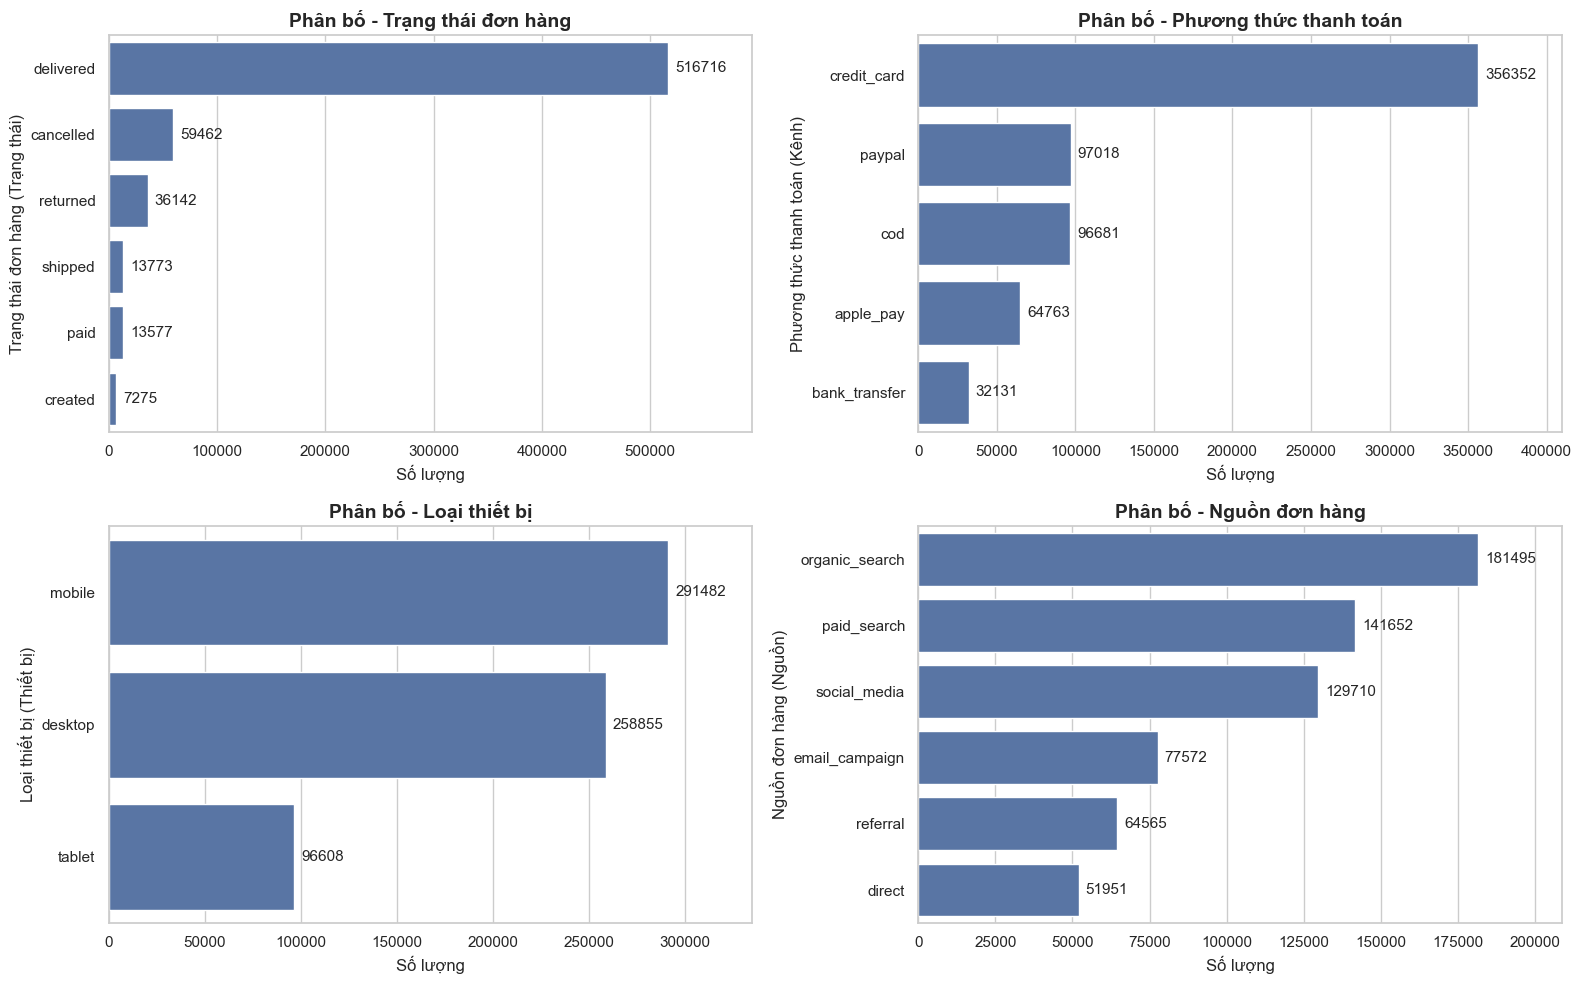

In [8]:
COL_INFO = {
    'order_status': {'name': 'Trạng thái đơn hàng', 'unit': 'Trạng thái'},
    'payment_method': {'name': 'Phương thức thanh toán', 'unit': 'Kênh'},
    'device_type': {'name': 'Loại thiết bị', 'unit': 'Thiết bị'},
    'order_source': {'name': 'Nguồn đơn hàng', 'unit': 'Nguồn'}
}

# 2. Hàm vẽ biểu đồ phân bố Categorical (Bar chart ngang)
def plot_horizontal_bar_chart(df, cate_cols_names):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    # Thiết lập kích thước: Tăng chiều ngang để có không gian cho số liệu
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows)) 
    axes = axes.flatten()

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]
        
        if col_name in df.columns:
            # Lấy tần suất xuất hiện, điền 'Không xác định' cho các giá trị bị thiếu (NaN)
            val_counts = df[col_name].fillna('Không xác định').value_counts()
            
            # Xử lý: Lấy top 30, nhóm phần còn lại thành 'Khác'
            TOP = 30
            if len(val_counts) > TOP:
                top9 = val_counts.iloc[:(TOP - 1)]
                other_sum = val_counts.iloc[(TOP - 1):].sum()
                plot_data = pd.concat([top9, pd.Series({'Khác': other_sum})])
            else:
                plot_data = val_counts
                
            # Đảm bảo index là kiểu chuỗi
            plot_data.index = plot_data.index.astype(str)
            
            # Vẽ Bar chart ngang (Thêm palette viridis cho sinh động)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)
            
            # Lấy thông tin Tên và Đơn vị từ Từ điển
            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'Loại'}) 
            
            # Cài đặt tiêu đề và nhãn
            ax.set_title(f"Phân bố - {info['name']}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Số lượng", fontsize=12)
            ax.set_ylabel(f"{info['name']} ({info['unit']})", fontsize=12)
            
            # Thêm con số thực tế bên phải mỗi thanh bar
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f'{int(width)}', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=11, 
                                xytext=(5, 0), textcoords='offset points')
            
            # Mở rộng giới hạn trục x thêm 15% để số liệu (annotate) không bị che khuất
            ax.set_xlim(0, max(plot_data.values) * 1.15)
            
        else:
            ax.set_visible(False)
            
    # Ẩn các trục không sử dụng nếu số lượng cột là số lẻ
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# 3. Chạy hàm với các cột cần vẽ
cate_cols = ['order_status', 'payment_method', 'device_type', 'order_source']
plot_horizontal_bar_chart(orders_df, cate_cols)

**Nhận xét:**

- **Quan sát:**
    - Phân bố - Trạng thái đơn hàng: Đa số tuyệt đối các đơn hàng ở trạng thái hoàn thành ("delivered" với 516.716 đơn). Tuy nhiên, lượng đơn bị hủy ("cancelled" - 59.462) và hoàn trả ("returned" - 36.142) cũng chiếm một tỷ trọng đáng kể. Nhóm đang xử lý hoặc chờ giao ("shipped", "paid", "created") chiếm tỷ lệ rất nhỏ.
    - Phân bố - Phương thức thanh toán: Thẻ tín dụng ("credit_card") là kênh thanh toán áp đảo hoàn toàn với 356.352 giao dịch. Theo sau là "paypal" (97.018) và thanh toán khi nhận hàng ("cod" - 96.681) với số lượng gần tương đương nhau. 
    - Phân bố - Loại thiết bị: Điện thoại di động ("mobile" - 291.482) và máy tính để bàn ("desktop" - 258.855) là hai thiết bị dẫn đầu, tạo thành thế cân bằng trong hành vi mua sắm. Máy tính bảng ("tablet") có số lượng ít hơn hẳn (96.608).
    - Phân bố - Nguồn đơn hàng: Nguồn tìm kiếm tự nhiên ("organic_search" - 181.495) mang lại nhiều đơn hàng nhất. Tiếp nối là các kênh trả phí ("paid_search" - 141.652) và mạng xã hội ("social_media" - 129.710).

- **Insights:**
    - Về Trạng thái đơn hàng: Hiệu suất vận hành chuỗi cung ứng tổng thể là rất tốt (tỷ lệ delivered cao). Tuy nhiên, tổng lượng đơn hàng "hỏng" (cancelled + returned) lên tới gần 100.000 đơn là một "nút thắt" (bottleneck) lớn, gây hao tổn chi phí logistics ngược (reverse logistics) và ảnh hưởng trực tiếp đến biên lợi nhuận ròng.
    - Về Phương thức thanh toán: Tệp khách hàng có mức độ số hóa cao, ưu tiên thanh toán trả trước qua thẻ tín dụng và ví điện tử (PayPal, Apple Pay). Việc tỷ lệ COD duy trì ở mức trung bình - thấp giúp doanh nghiệp giảm thiểu đáng kể rủi ro "bom hàng" và tối ưu dòng tiền (cash flow).
    - Về Trải nghiệm người dùng: Hành vi mua sắm đa kênh (omnichannel) đang diễn ra mạnh mẽ. Khách hàng thoải mái ra quyết định mua hàng trên cả giao diện di động lẫn máy tính cá nhân.
    - Về Marketing: Thương hiệu có nền tảng SEO/Organic rất vững chắc khi mang về lượng chuyển đổi cao nhất mà không tốn chi phí click. Đồng thời, sự đóng góp đồng đều từ Paid Search và Social Media cho thấy chiến lược phân bổ đa kênh (multi-channel acquisition) đang hoạt động hiệu quả.

- **Gợi ý hành động:**
    - Khắc phục tỷ lệ rớt đơn: Cần tiến hành phân tích sâu (Deep-dive) nguyên nhân dẫn đến Cancelled và Returned. Phân tách dữ liệu xem các đơn bị hủy/hoàn này tập trung ở nhóm sản phẩm nào, nguồn traffic nào hay khu vực nào để có biện pháp can thiệp (ví dụ: cải thiện mô tả sản phẩm, nâng cao chất lượng đóng gói, hoặc review lại khâu CSKH).
    - Tối ưu hóa UI/UX: Do lượng giao dịch chia đều cho cả Mobile và Desktop, đội ngũ phát triển sản phẩm cần đảm bảo trải nghiệm người dùng (UX) và luồng thanh toán (checkout flow) phải thực sự mượt mà và đồng nhất (responsive) trên cả hai nền tảng này.
    - Tối ưu chi phí chuyển đổi (CAC): Phân tích chỉ số ROI của các chiến dịch "paid_search" và "social_media". So sánh chất lượng đơn hàng (giá trị đơn trung bình, tỷ lệ hủy) từ các nguồn này so với "organic_search" để có chiến lược phân bổ ngân sách marketing (budget allocation) khôn ngoan hơn trong quý tới.
    - Thúc đẩy thanh toán trả trước: Tiếp tục duy trì lợi thế thanh toán số. Có thể thử nghiệm các chương trình khuyến mãi nhỏ (ví dụ: Freeship, giảm thêm 2-5%) cho các đơn hàng thanh toán qua Apple Pay hoặc Bank Transfer để giảm sự phụ thuộc vào Credit Card, đồng thời kéo giảm tỷ lệ COD xuống mức thấp hơn nữa.

### 1.1.3. Biến thời gian 

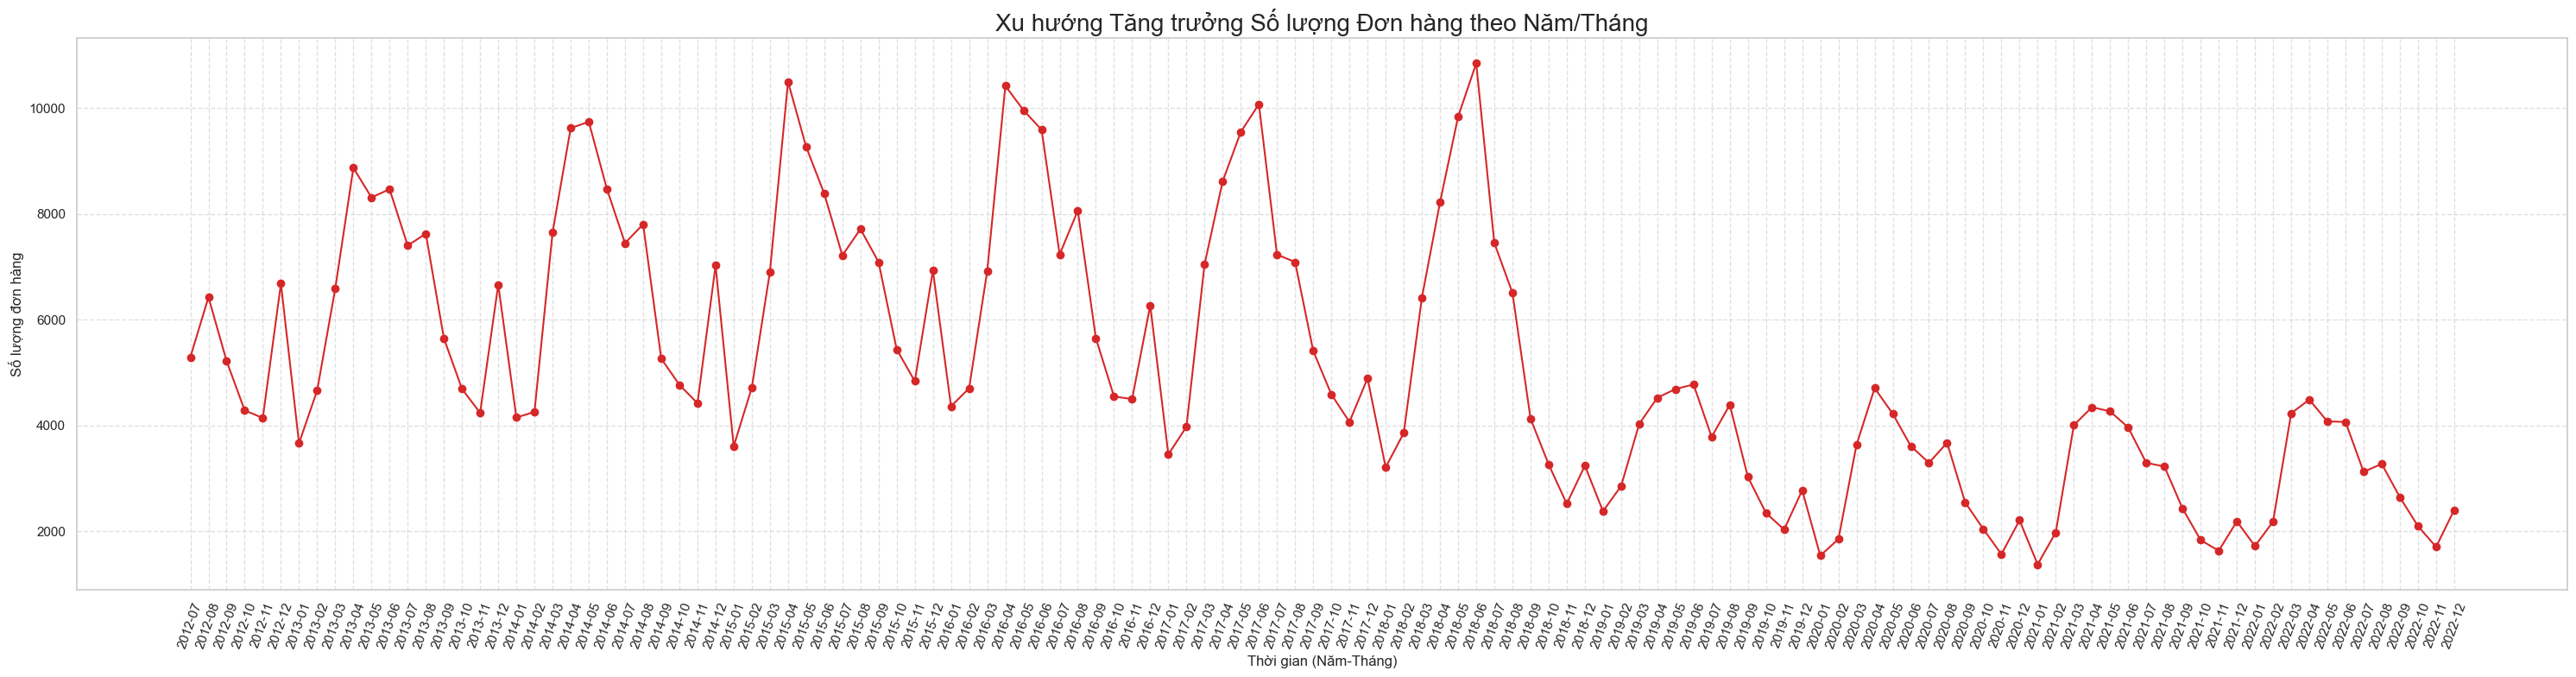

In [37]:
# 1. Xử lý dữ liệu thời gian
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['year_month'] = orders_df['order_date'].dt.to_period('M') # Lấy Năm-Tháng

# 2. Tổng hợp dữ liệu
trend_df = orders_df.groupby('year_month').size().reset_index(name='order_count')
trend_df['year_month'] = trend_df['year_month'].astype(str) # Ép kiểu chuỗi để vẽ trục X đẹp hơn

# 3. Vẽ biểu đồ đường
fig, ax = plt.subplots(figsize=(30, 8))

ax.plot(trend_df['year_month'], trend_df['order_count'], color='tab:red', marker='o', linestyle='-')
ax.set_title('Xu hướng Tăng trưởng Số lượng Đơn hàng theo Năm/Tháng', fontsize=20)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Số lượng đơn hàng')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

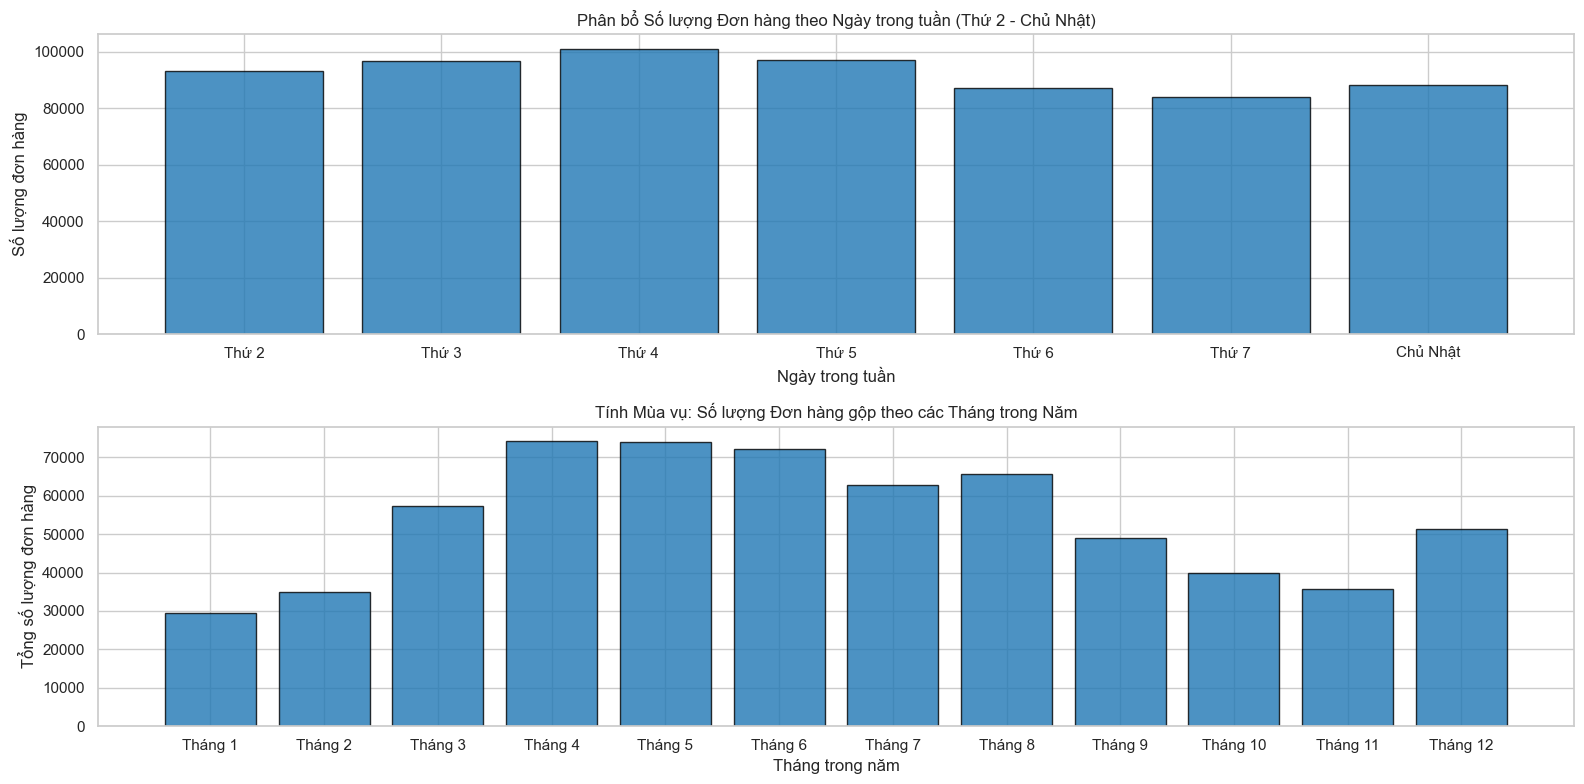

In [36]:
# 1. Xử lý dữ liệu thời gian
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['day_of_week'] = orders_df['order_date'].dt.dayofweek    # Lấy Thứ (0=Thứ 2, 6=Chủ nhật)
orders_df['month'] = orders_df['order_date'].dt.month              # Lấy Tháng (1 đến 12)

# 2. Tổng hợp dữ liệu
# --- Theo Ngày trong tuần ---
dow_df = orders_df.groupby('day_of_week').size().reset_index(name='order_count')
days_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
dow_df['day_name'] = dow_df['day_of_week'].map(days_map)

# --- Theo Mùa vụ (Tháng trong năm) ---
season_df = orders_df.groupby('month').size().reset_index(name='order_count')
months = ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 
          'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12']

# 3. Vẽ 2 biểu đồ cột
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Đồ thị trên: Phân bổ theo Ngày trong tuần
axes[0].bar(dow_df['day_name'], dow_df['order_count'], color='tab:blue', edgecolor='black', alpha=0.8)
axes[0].set_title('Phân bổ Số lượng Đơn hàng theo Ngày trong tuần (Thứ 2 - Chủ Nhật)')
axes[0].set_xlabel('Ngày trong tuần')
axes[0].set_ylabel('Số lượng đơn hàng')

# Đồ thị dưới: Phân bổ theo Mùa vụ / Tháng
axes[1].bar(months, season_df['order_count'], color='tab:blue', edgecolor='black', alpha=0.8)
axes[1].set_title('Tính Mùa vụ: Số lượng Đơn hàng gộp theo các Tháng trong Năm')
axes[1].set_xlabel('Tháng trong năm')
axes[1].set_ylabel('Tổng số lượng đơn hàng')

fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
    - **Xu hướng theo thời gian (Time-series Trend):** Biểu đồ đường thể hiện sự biến động mạnh về số lượng đơn hàng từ năm 2012 đến 2022. Dữ liệu có tính chu kỳ với các đỉnh (peak) và đáy (trough) lặp lại liên tục. Tuy nhiên, xu hướng chung từ sau năm 2018 đến 2022 là giảm sút rõ rệt, các đỉnh của những năm sau thấp hơn hẳn so với giai đoạn 2015-2018 (đỉnh cao nhất đạt trên 10.000 đơn).
    - **Phân bổ theo ngày trong tuần (Day of Week):** Lượng đơn hàng phân bổ khá đồng đều giữa các ngày, dao động trong khoảng 80.000 - 100.000 đơn. Nhóm ngày giữa tuần (Thứ 3, Thứ 4, Thứ 5) ghi nhận lượng đơn cao nhất, đặc biệt là Thứ 4. Các ngày cuối tuần (Thứ 7, Chủ Nhật) có sự sụt giảm nhẹ nhưng không quá chênh lệch so với ngày thường.
    - **Tính mùa vụ theo tháng (Seasonality):** Phân bố theo tháng có sự khác biệt rất lớn, minh chứng cho tính mùa vụ mạnh. Lượng đơn hàng tập trung dày đặc nhất vào Quý 2 (Tháng 4, 5, 6) với mức trên 70.000 đơn mỗi tháng. Ngược lại, giai đoạn đầu năm (Tháng 1, 2) và cuối năm (Tháng 10, 11) là thời điểm thấp điểm nhất, lượng đơn sụt giảm chỉ còn khoảng một nửa so với mùa cao điểm.

- **Insights:**
    - **Về Xu hướng dài hạn:** Doanh nghiệp đang đối mặt với sự suy giảm về lượng đơn hàng trong khoảng 3-4 năm trở lại đây. Chu kỳ lên xuống lặp lại cho thấy sự phụ thuộc lớn vào thời điểm bán hàng trong năm, nhưng "đỉnh sóng" đang ngày càng thấp đi, báo hiệu có thể thị trường đã bão hòa, có thêm đối thủ cạnh tranh mới, hoặc hành vi người tiêu dùng đã thay đổi.
    - **Về Hành vi mua sắm trong tuần:** Khách hàng có thói quen "chốt đơn" nhiều nhất vào giữa tuần (Thứ 4). Điều này có thể xuất phát từ tâm lý muốn đặt hàng sớm để kịp nhận bưu kiện trước khi cuối tuần nghỉ ngơi. Sự sụt giảm vào Thứ 7 cho thấy vào ngày nghỉ, khách hàng có xu hướng tham gia các hoạt động offline hơn là mua sắm trực tuyến.
    - **Về Tính mùa vụ:** Danh mục sản phẩm/dịch vụ này gắn liền với nhu cầu tiêu dùng vào mùa hè (Tháng 4 - Tháng 8). Ngược lại, nó không phải là ưu tiên mua sắm trong dịp lễ Tết đầu năm hay mùa thu đông cuối năm. Đây có thể là đặc trưng của các ngành hàng như thời trang xuân/hè, thiết bị làm mát, hoặc dịch vụ du lịch hè.

- **Gợi ý hành động:**
    - **Chiến lược cho mùa thấp điểm:** Cần thiết kế các chương trình Mega Campaign, Flash Sale hoặc Bundle Deal (bán combo) vào các tháng 1, 2 và 10, 11 để kích cầu, duy trì dòng tiền và giải phóng hàng tồn kho. Đối với sự sụt giảm cuối tuần, có thể cân nhắc các voucher độc quyền "Weekend Only" để thúc đẩy tỷ lệ chuyển đổi.
    - **Tối ưu hóa nguồn lực mùa cao điểm:** Phân bổ ngân sách Marketing (Ads spend) dồn lực vào giai đoạn Tháng 3 - Tháng 6 và các ngày giữa tuần (Thứ 3 - Thứ 5) để đón đầu làn sóng mua sắm. Đồng thời, cần chuẩn bị sẵn sàng chuỗi cung ứng, nhân sự kho bãi và đội ngũ CSKH để đáp ứng lượng đơn tăng đột biến.
    - **Deep-dive nguyên nhân suy giảm dài hạn:** Cần thực hiện phân tích sâu (Cohort Analysis, Churn Rate) kết hợp với dữ liệu định tính để tìm ra nguyên nhân gốc rễ của việc giảm số lượng đơn hàng từ năm 2019. Nếu là do cạnh tranh, cần đánh giá lại chiến lược về giá (Pricing) và định vị sản phẩm; nếu do chất lượng dịch vụ, cần cải thiện trải nghiệm khách hàng (Customer Experience).

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table